# Data Leakage Detection Analysis

This notebook performs comprehensive data leakage detection using multiple approaches:
1. Adversarial Validation - Train a model to distinguish between train and test sets
2. Feature Importance Analysis - Identify suspiciously predictive features
3. Temporal Permutation Tests - Ensure no future information leaks into historical data
4. Correlation Analysis - Detect indirect leakage through feature correlations

The presence of data leakage can lead to overoptimistic model performance and poor generalization.

In [2]:
# Import required libraries
import sys
sys.path.insert(0, "../../run")
from const import REPO_PATH
from experiment_config import TRAINGING_CONFIG

sys.path.insert(1, f"{REPO_PATH}")
from src.model.experiment_utils import *
from src.model.model_utils import *

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, precision_score, recall_score
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import scipy.stats as stats

In [3]:
# Configuration for data leakage analysis
targets_to_investigate = ['home_goals', 'away_goals']
MIN_IMPORTANCE_THRESHOLD = 0.01  # Minimum importance threshold for permutation testing

## 1. Data Loading and Preparation

Load feature and target dataframes following the same structure as baseline.ipynb. We'll:
1. Load data from multiple seasons
2. Convert dates to datetime format
3. Align feature and target dataframes
4. Handle missing values

In [4]:
# Load features and targets
features_path = f"{TRAINGING_CONFIG['features_path']}/all_combined_features_2017-24.csv"
seasons = sorted(TRAINGING_CONFIG['seasons'])

# Load target data from multiple seasons
target_dfs = [pd.read_csv(f"{TRAINGING_CONFIG['processed_data_path']}/{season}/all_target_df.csv") 
              for season in seasons[1:]]

# Convert dates to datetime
for df in target_dfs:
    df['date'] = pd.to_datetime(df['date'])
target_df = pd.concat(target_dfs, ignore_index=True)

# Load and prepare feature data
feature_df = pd.read_csv(features_path)
feature_df['date'] = pd.to_datetime(feature_df['date'])

# Align features and targets
feature_df, target_df = align_on_keys(feature_df, target_df, TRAINGING_CONFIG['key_columns'])

# Handle missing values
feature_df.fillna(-1, inplace=True)

print("Feature DataFrame Shape:", feature_df.shape)
print("Target DataFrame Shape:", target_df.shape)
print("\nFeature columns:", len(feature_df.columns))
print("Date range:", feature_df['date'].min(), "to", feature_df['date'].max())

Feature DataFrame Shape: (2660, 2729)
Target DataFrame Shape: (2660, 13)

Feature columns: 2729
Date range: 2018-08-10 00:00:00 to 2025-05-25 00:00:00


## 2. Adversarial Validation

Adversarial validation helps detect data leakage by training a model to distinguish between training and test sets. 
If the model performs significantly better than random chance (AUC > 0.5), it suggests:
1. Potential data leakage
2. Distribution shift between train and test sets
3. Temporal patterns that might need attention

Adversarial Validation AUC: 0.985 ± 0.003

Top 20 most important features for distinguishing train/test sets:
                                          feature  importance
128         prev_season_avg_home_home_carries_cpa    0.018780
1974             away_lag2_away_performance_recov    0.016014
68          prev_season_avg_home_home_player_prgp    0.014374
253    prev_season_avg_home_away_aerial_duels_won    0.013192
468   prev_season_avg_away_away_performance_recov    0.012331
289       prev_season_avg_away_home_total_prgdist    0.012126
1759             away_lag1_away_performance_recov    0.011730
147   prev_season_avg_home_home_aerial_duels_lost    0.010912
469    prev_season_avg_away_away_aerial_duels_won    0.010025
252   prev_season_avg_home_away_performance_recov    0.009789
71           prev_season_avg_home_home_total_cmp%    0.009730
1652             away_lag1_home_performance_recov    0.009717
344         prev_season_avg_away_home_carries_cpa    0.009647
73        prev_season_

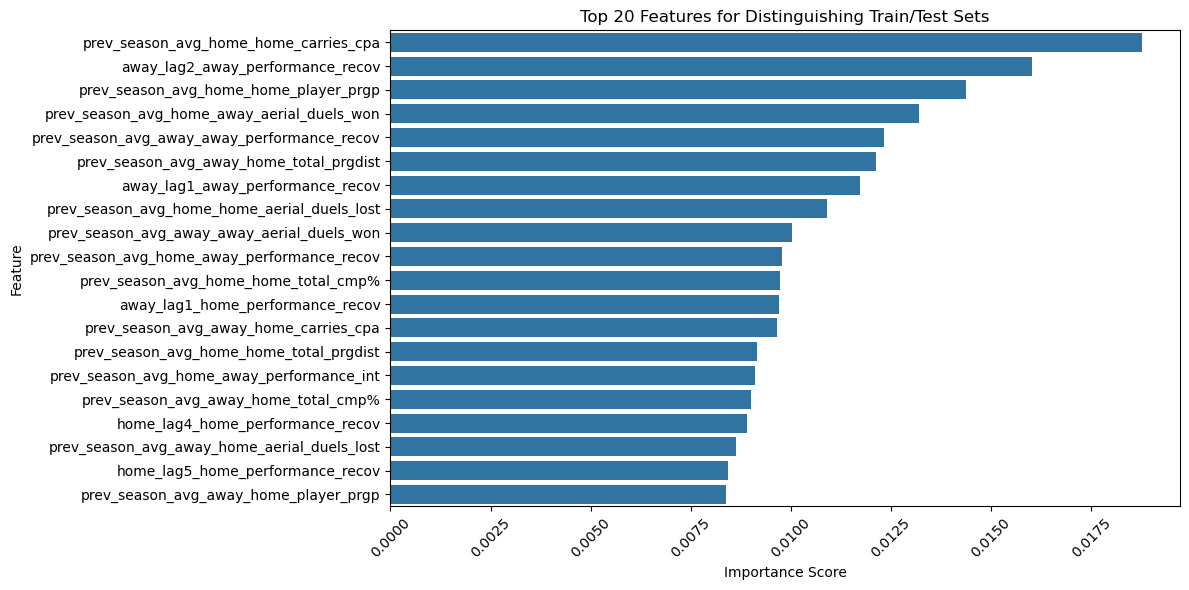


Statistical Analysis:
Z-score: 365.834
P-value: 0.000
Interpretation:


In [5]:
def perform_adversarial_validation(feature_df, test_size=0.2, n_splits=5):
    """
    Perform adversarial validation to detect potential data leakage.
    Returns AUC scores and feature importances.
    """
    # Create temporal split
    split_date = feature_df['date'].sort_values().iloc[int(len(feature_df) * (1 - test_size))]
    
    # Create binary labels: 0 for train, 1 for test
    is_test = (feature_df['date'] >= split_date).astype(int)
    
    # Prepare features (exclude date and other non-feature columns)
    feature_cols = [col for col in feature_df.columns 
                   if col not in TRAINGING_CONFIG['key_columns']]
    X = feature_df[feature_cols]
    
    # Initialize results storage
    aucs = []
    feature_importances = []
    
    # Perform k-fold CV for robust estimates
    for i in range(n_splits):
        # Split data for validation
        X_train, X_val, y_train, y_val = train_test_split(
            X, is_test, test_size=0.2, random_state=i
        )
        
        # Train Random Forest
        rf = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=i)
        rf.fit(X_train, y_train)
        
        # Get predictions and AUC
        y_pred = rf.predict_proba(X_val)[:, 1]
        auc = roc_auc_score(y_val, y_pred)
        aucs.append(auc)
        
        # Store feature importances
        feature_importances.append(rf.feature_importances_)
    
    # Average results across splits
    mean_auc = np.mean(aucs)
    std_auc = np.std(aucs)
    mean_importances = np.mean(feature_importances, axis=0)
    
    # Create importance DataFrame
    importance_df = pd.DataFrame({
        'feature': feature_cols,
        'importance': mean_importances
    }).sort_values('importance', ascending=False)
    
    return mean_auc, std_auc, importance_df

# Run adversarial validation
mean_auc, std_auc, importances = perform_adversarial_validation(feature_df)

print(f"Adversarial Validation AUC: {mean_auc:.3f} ± {std_auc:.3f}")
print("\nTop 20 most important features for distinguishing train/test sets:")
print(importances.head(20))

# Plot feature importances
plt.figure(figsize=(12, 6))
sns.barplot(data=importances.head(20), x='importance', y='feature')
plt.title('Top 20 Features for Distinguishing Train/Test Sets')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Analyze AUC significance
null_hypothesis_auc = 0.5
z_score = (mean_auc - null_hypothesis_auc) / (std_auc / np.sqrt(5))  # 5 splits
p_value = 2 * (1 - stats.norm.cdf(abs(z_score)))  # two-tailed test

print(f"\nStatistical Analysis:")
print(f"Z-score: {z_score:.3f}")
print(f"P-value: {p_value:.3f}")
print("Interpretation:")
if p_value < 0.05:
    print("WARNING: Significant evidence of data leakage or distribution shift detected!")
else:
    print("No significant evidence of data leakage detected.")

## 3. Permutation Tests for Feature Importance

Permutation tests help identify features that might be "too good to be true" by:
1. Computing feature importance scores for each target variable
2. Comparing against randomized target permutations
3. Identifying features with suspiciously high predictive power

Features with very low p-values might be leaking information from the target.


Analyzing target: home_goals

Testing 2 features that meet the importance threshold of 0.01

Testing 2 features that meet the importance threshold of 0.01


Running permutations for home_goals: 100%|██████████| 100/100 [00:03<00:00, 25.71it/s]



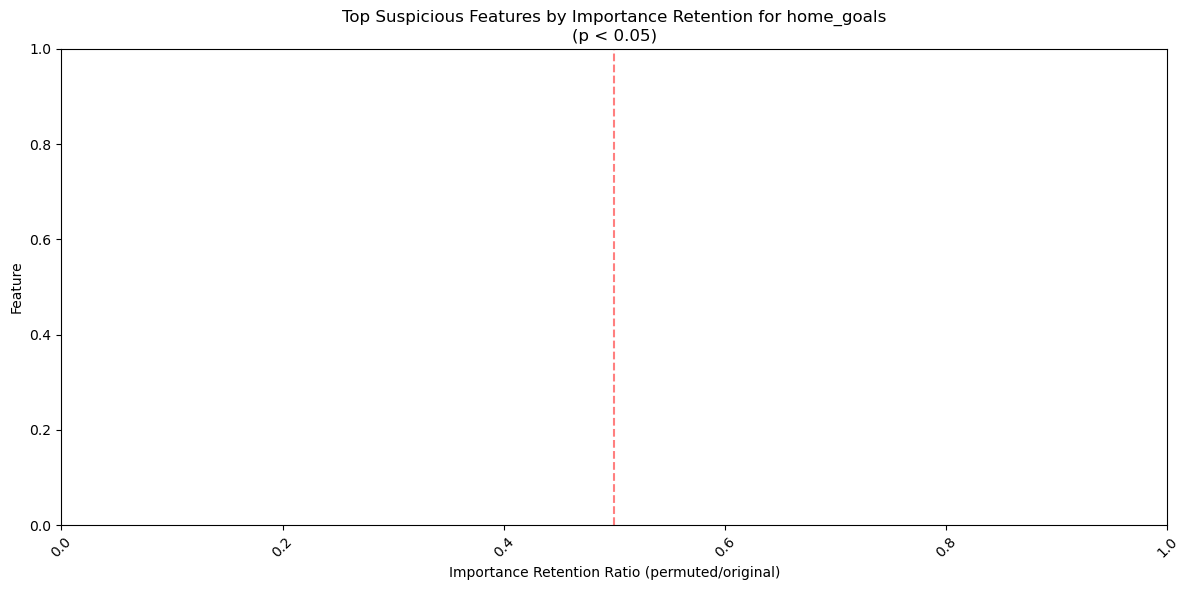

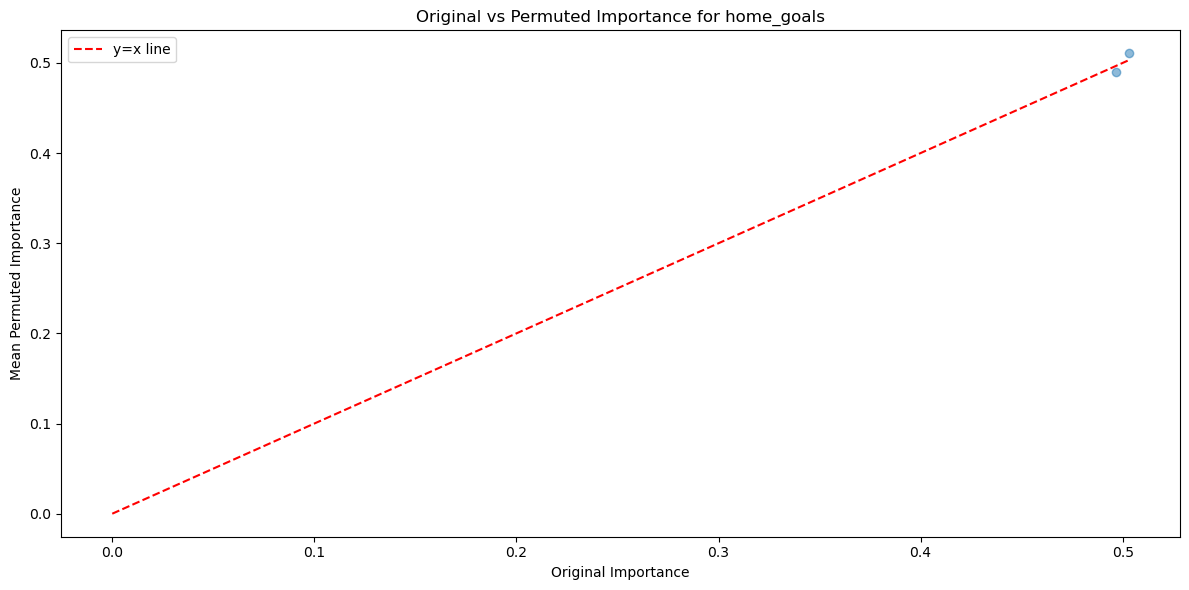


Most suspicious features (high importance retention):
Empty DataFrame
Columns: [feature, original_importance, permuted_importance, importance_retention, z_score, p_value]
Index: []

Analyzing target: away_goals

Testing 1 features that meet the importance threshold of 0.01

Testing 1 features that meet the importance threshold of 0.01


Running permutations for away_goals: 100%|██████████| 100/100 [00:03<00:00, 25.02it/s]



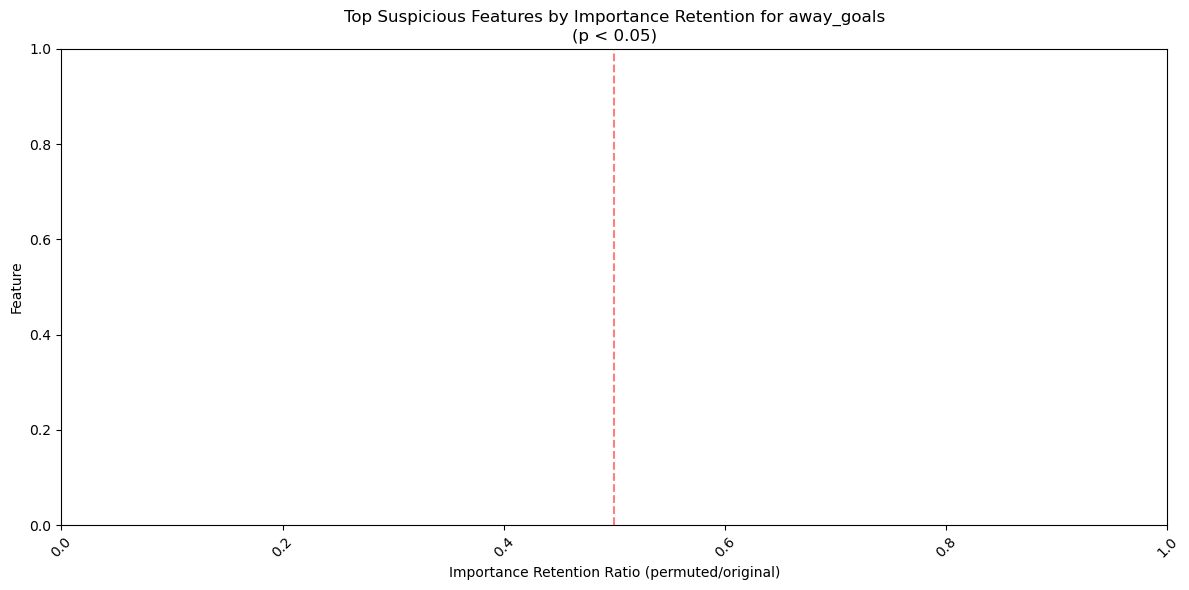

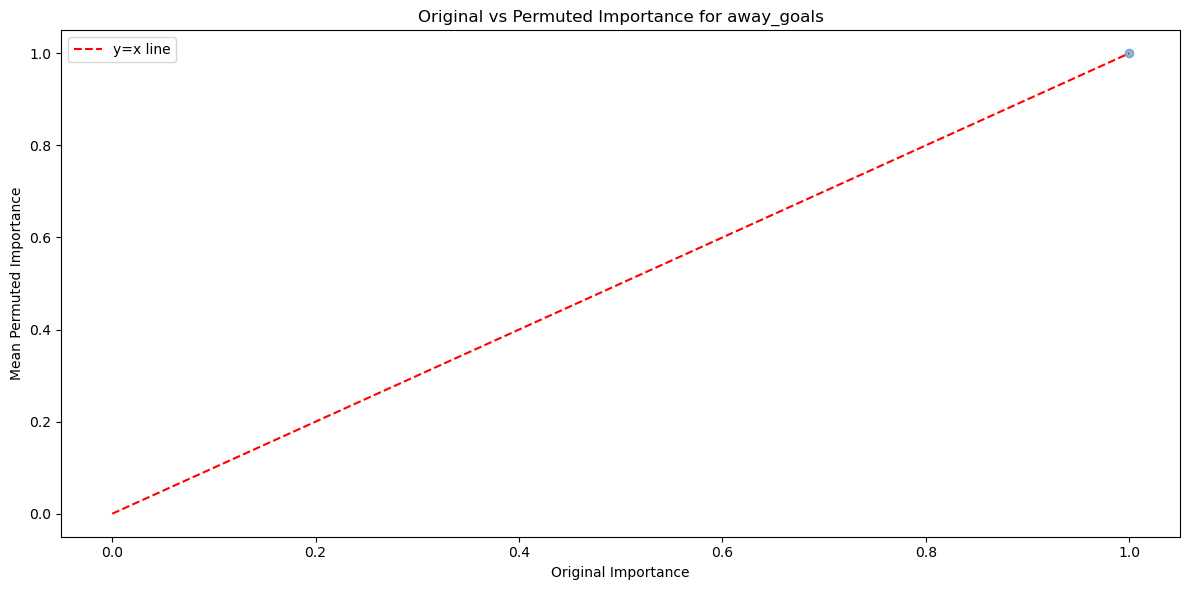


Most suspicious features (high importance retention):
Empty DataFrame
Columns: [feature, original_importance, permuted_importance, importance_retention, z_score, p_value]
Index: []


In [6]:
def perform_permutation_test(feature_df, target_df, target_col, n_permutations=100):
    """
    Perform permutation test to detect suspiciously predictive features.
    Only tests features that meet the minimum importance threshold.
    
    Returns feature importance scores and their statistical significance.
    """
    # Prepare features
    feature_cols = [col for col in feature_df.columns 
                   if col not in TRAINGING_CONFIG['key_columns']]
    X = feature_df[feature_cols]
    y = target_df[target_col]
    
    # First pass to identify important features
    rf_initial = RandomForestClassifier(n_estimators=50, max_depth=3, random_state=42)
    rf_initial.fit(X, y)
    initial_importance = rf_initial.feature_importances_
    
    # Filter features by importance
    important_features = [col for col, imp in zip(feature_cols, initial_importance) 
                         if imp >= MIN_IMPORTANCE_THRESHOLD]
    print(f"\nTesting {len(important_features)} features that meet the importance threshold of {MIN_IMPORTANCE_THRESHOLD}")
    
    if not important_features:
        print("No features meet the importance threshold!")
        return pd.DataFrame()
    
    # Use only important features for detailed permutation testing
    X_important = feature_df[important_features]
    
    # Original feature importance scores with important features only
    rf = RandomForestClassifier(n_estimators=50, max_depth=3, random_state=42)
    rf.fit(X_important, y)
    original_importance = rf.feature_importances_
    
    # Permutation scores
    perm_importance = np.zeros((n_permutations, len(important_features)))
    
    for i in tqdm(range(n_permutations), desc=f"Running permutations for {target_col}"):
        y_perm = np.random.permutation(y)
        rf_perm = RandomForestClassifier(n_estimators=50, max_depth=3, random_state=42)
        rf_perm.fit(X_important, y_perm)
        perm_importance[i] = rf_perm.feature_importances_
    
    # Calculate mean and std of permuted importances
    mean_perm_importance = np.mean(perm_importance, axis=0)
    std_perm_importance = np.std(perm_importance, axis=0)
    
    # Calculate p-values and relative importance retention
    p_values = np.mean(perm_importance >= original_importance.reshape(1, -1), axis=0)
    epsilon = 1e-10  # Small constant to avoid division by zero
    importance_retention = mean_perm_importance / (original_importance + epsilon)
    z_scores = (original_importance - mean_perm_importance) / np.maximum(std_perm_importance, epsilon)
    
    # Create results DataFrame
    results = pd.DataFrame({
        'feature': important_features,
        'original_importance': original_importance,
        'permuted_importance': mean_perm_importance,
        'importance_retention': importance_retention,
        'z_score': z_scores,
        'p_value': p_values,
        'significant': p_values < 0.05
    }).sort_values('importance_retention', ascending=False)
    
    return results

# Run permutation test for specified target columns
for target_col in targets_to_investigate:
    print(f"\nAnalyzing target: {target_col}")
    results = perform_permutation_test(feature_df, target_df, target_col)
    
    if not results.empty:
        # Plot importance retention for significant features
        plt.figure(figsize=(12, 6))
        suspicious_features = results[results['significant']].head(20)
        sns.barplot(data=suspicious_features, x='importance_retention', y='feature')
        plt.title(f'Top Suspicious Features by Importance Retention for {target_col}\n(p < 0.05)')
        plt.xlabel('Importance Retention Ratio (permuted/original)')
        plt.ylabel('Feature')
        plt.axvline(x=0.5, color='r', linestyle='--', alpha=0.5, 
                    label='50% retention threshold')
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()
        
        # Plot original vs permuted importance
        plt.figure(figsize=(12, 6))
        plt.scatter(results['original_importance'], 
                   results['permuted_importance'],
                   alpha=0.5)
        plt.plot([0, results['original_importance'].max()], 
                 [0, results['original_importance'].max()],
                 'r--', label='y=x line')
        plt.xlabel('Original Importance')
        plt.ylabel('Mean Permuted Importance')
        plt.title(f'Original vs Permuted Importance for {target_col}')
        plt.legend()
        plt.tight_layout()
        plt.show()
        
        print("\nMost suspicious features (high importance retention):")
        print(suspicious_features[['feature', 'original_importance', 
                                 'permuted_importance', 'importance_retention', 
                                 'z_score', 'p_value']].head(10))
        
        # Highlight very suspicious features
        very_suspicious = results[
            (results['significant']) & 
            (results['importance_retention'] > 0.5)  # Retains >50% importance
        ]
        
        if not very_suspicious.empty:
            print("\nWARNING - Very Suspicious Features (retain >50% importance after permutation):")
            print(very_suspicious[['feature', 'importance_retention', 'z_score', 'p_value']])

## 4. Temporal Correlation Analysis

This section analyzes temporal relationships between features and targets to detect:
1. Forward-looking features that might leak future information
2. Unexpected correlations across time periods
3. Temporal dependencies that might indicate data leakage

/Users/tianqihuang/anaconda3/envs/betbot/lib/python3.12/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/tianqihuang/anaconda3/envs/betbot/lib/python3.12/site-packages/numpy/lib/function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/Users/tianqihuang/anaconda3/envs/betbot/lib/python3.12/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/tianqihuang/anaconda3/envs/betbot/lib/python3.12/site-packages/numpy/lib/function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/Users/tianqihuang/anaconda3/envs/betbot/lib/python3.12/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/tianqihuang/anaconda3/envs/betbot/lib/python3.12/site-packages/numpy/lib/function_base.py:2898: Runtime

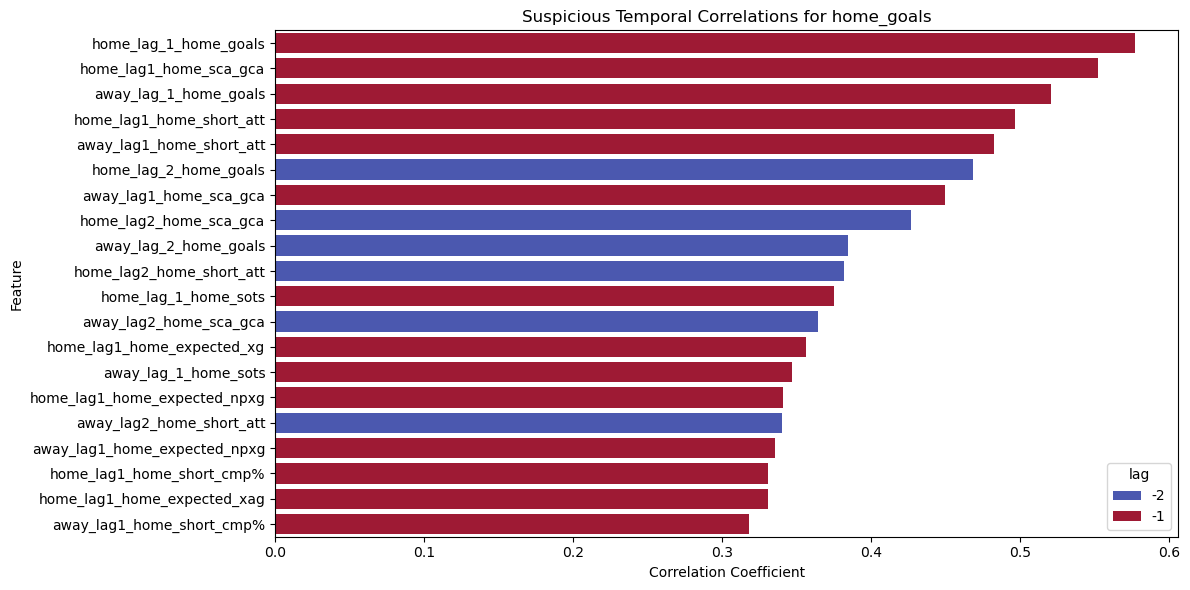


Suspicious correlations for home_goals:
                        feature  lag  correlation
10505     home_lag_1_home_goals   -1     0.577127
1941     home_lag1_home_sca_gca   -1     0.552047
10705     away_lag_1_home_goals   -1     0.520438
2029   home_lag1_home_short_att   -1     0.496379
6329   away_lag1_home_short_att   -1     0.482731
10544     home_lag_2_home_goals   -2     0.468051
6241     away_lag1_home_sca_gca   -1     0.449360
2800     home_lag2_home_sca_gca   -2     0.426438
10744     away_lag_2_home_goals   -2     0.384211
2888   home_lag2_home_short_att   -2     0.381505


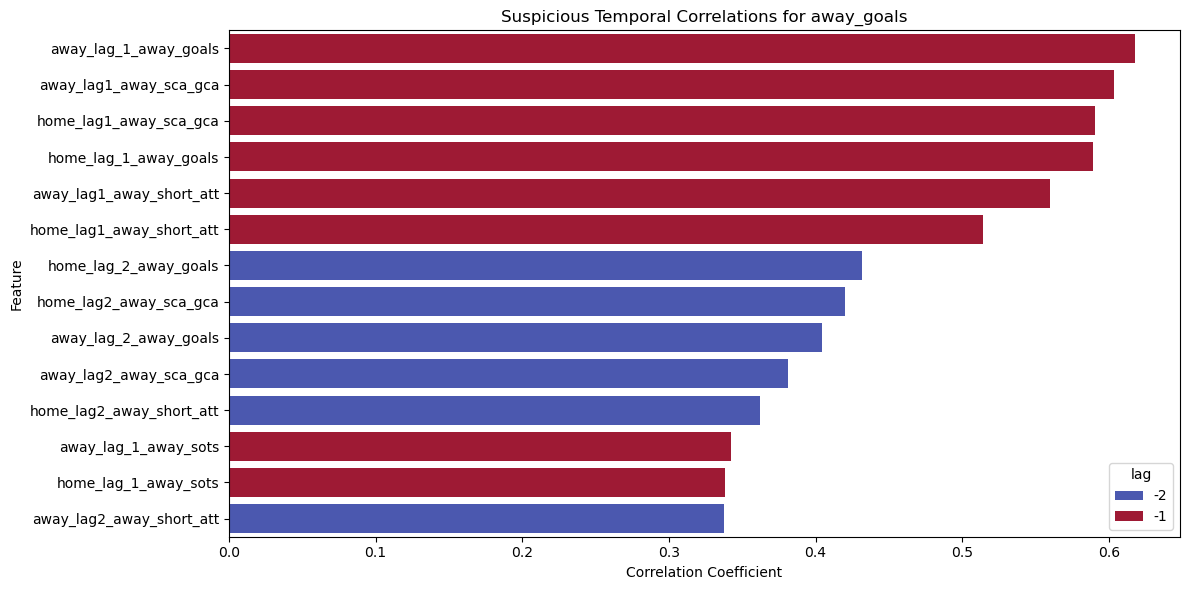


Suspicious correlations for away_goals:
                        feature  lag  correlation
21613     away_lag_1_away_goals   -1     0.617552
17573    away_lag1_away_sca_gca   -1     0.603652
13273    home_lag1_away_sca_gca   -1     0.590241
21413     home_lag_1_away_goals   -1     0.589431
17661  away_lag1_away_short_att   -1     0.560000
13361  home_lag1_away_short_att   -1     0.514094
21452     home_lag_2_away_goals   -2     0.431523
14132    home_lag2_away_sca_gca   -2     0.420340
21652     away_lag_2_away_goals   -2     0.404569
18432    away_lag2_away_sca_gca   -2     0.381268


In [7]:
def analyze_temporal_correlations(feature_df, target_df, window_size='7D'):
    """
    Analyze temporal correlations between features and targets.
    Returns correlation matrix and suspicious correlations.
    """
    # Prepare data
    feature_cols = [col for col in feature_df.columns 
                   if col not in TRAINGING_CONFIG['key_columns']]
    
    # Create time windows
    feature_df['time_window'] = pd.to_datetime(feature_df['date']).dt.floor(window_size)
    
    correlations = []
    for target_col in targets_to_investigate:
        # Calculate rolling means for features and target
        for feature_col in feature_cols:
            feature_means = feature_df.groupby('time_window')[feature_col].mean()
            target_means = target_df.groupby(
                pd.to_datetime(target_df['date']).dt.floor(window_size))[target_col].mean()
            
            # Calculate correlations at different lags
            for lag in range(-2, 3):  # Check -2 to +2 time windows
                if lag != 0:  # Skip lag 0 as it's expected to have correlations
                    lagged_corr = feature_means.corr(target_means.shift(-lag))
                    correlations.append({
                        'target': target_col,
                        'feature': feature_col,
                        'lag': lag,
                        'correlation': lagged_corr
                    })
    
    corr_df = pd.DataFrame(correlations)
    
    # Identify suspicious correlations (high correlation at future lags)
    suspicious_corr = corr_df[
        (corr_df['lag'] < 0) &  # Future information
        (abs(corr_df['correlation']) > 0.3)  # Strong correlation
    ].sort_values('correlation', key=abs, ascending=False)
    
    return corr_df, suspicious_corr

# Perform temporal correlation analysis
corr_df, suspicious_corr = analyze_temporal_correlations(feature_df, target_df)

# Plot temporal correlations
for target_col in targets_to_investigate:
    # Filter correlations for this target
    target_corr = suspicious_corr[suspicious_corr['target'] == target_col]
    
    if not target_corr.empty:
        plt.figure(figsize=(12, 6))
        sns.barplot(data=target_corr.head(20), 
                   x='correlation', 
                   y='feature', 
                   hue='lag',
                   palette='coolwarm')
        plt.title(f'Suspicious Temporal Correlations for {target_col}')
        plt.xlabel('Correlation Coefficient')
        plt.ylabel('Feature')
        plt.tight_layout()
        plt.show()
        
        print(f"\nSuspicious correlations for {target_col}:")
        print(target_corr[['feature', 'lag', 'correlation']].head(10))
    else:
        print(f"\nNo suspicious temporal correlations found for {target_col}")

## 5. Summary and Recommendations

### Key Findings to Review:

1. **Adversarial Validation Results**
   - AUC significantly > 0.5 indicates potential leakage or distribution shift
   - Check top features that distinguish train/test sets

2. **Permutation Test Results**
   - Features with very low p-values might be leaking information
   - Review feature generation process for suspicious features

3. **Temporal Correlation Findings**
   - Features showing strong correlations with future targets need investigation
   - Check for accidental future information leaks

### Recommended Actions:

1. For features identified as suspicious:
   - Review feature generation code
   - Verify temporal boundaries are respected
   - Consider removing or modifying problematic features

2. For temporal correlations:
   - Ensure feature calculations only use historical data
   - Add explicit checks in feature generation pipeline

3. For train/test separation:
   - Implement stricter temporal splits
   - Add validation checks in the training pipeline